In [1]:
import subprocess, sys

required = [
    "tensorflow", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "opencv-python-headless", "pillow",
    "shap", "kagglehub"
]

for pkg in required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed successfully.")


✅ All packages installed successfully.


In [2]:
import os, random, warnings, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, RocCurveDisplay)


warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Reproducibility seeds ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.20.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import kagglehub

# Download the dataset (cached after first run)
raw_path = kagglehub.dataset_download(
    "navoneel/brain-mri-images-for-brain-tumor-detection"
)
print(f"📦 Dataset downloaded to: {raw_path}")

# Explore directory structure
for root, dirs, files in os.walk(raw_path):
    level = root.replace(raw_path, "").count(os.sep)
    indent = "  " * level
    n_imgs = sum(1 for f in files if f.lower().endswith((".jpg", ".jpeg", ".png")))
    print(f"{indent}{os.path.basename(root)}/  ({n_imgs} images)")


Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
📦 Dataset downloaded to: /kaggle/input/brain-mri-images-for-brain-tumor-detection
brain-mri-images-for-brain-tumor-detection/  (0 images)
  no/  (98 images)
  yes/  (155 images)
  brain_tumor_dataset/  (0 images)
    no/  (98 images)
    yes/  (155 images)


In [4]:
# ── Gather all image paths ────────────────────────────────────────────────
RAW_PATH = raw_path          # path returned by kagglehub
DATA_DIR = "/tmp/brain_data"

IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 30
CLASSES    = ["no", "yes"]   # 0 = no tumor, 1 = tumor

all_images = {"yes": [], "no": []}

for root, _, files in os.walk(RAW_PATH):
    folder = os.path.basename(root).lower()
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            full = os.path.join(root, f)
            if "yes" in folder:
                all_images["yes"].append(full)
            elif "no" in folder:
                all_images["no"].append(full)

print(f"  Tumor (yes)    : {len(all_images['yes'])} images")
print(f"  No Tumor (no)  : {len(all_images['no'])} images")
print(f"  Total          : {sum(len(v) for v in all_images.values())} images")


  Tumor (yes)    : 310 images
  No Tumor (no)  : 196 images
  Total          : 506 images


In [5]:
def build_split(image_dict, out_dir, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Stratified train/val/test split, copies files to directory tree."""
    rng = random.Random(seed)
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)

    counts = {}
    for cls, paths in image_dict.items():
        shuffled = paths.copy()
        rng.shuffle(shuffled)
        n        = len(shuffled)
        n_test   = max(1, int(n * test_ratio))
        n_val    = max(1, int(n * val_ratio))

        splits = {
            "train": shuffled[n_test + n_val:],
            "val"  : shuffled[n_test: n_test + n_val],
            "test" : shuffled[:n_test],
        }
        counts[cls] = {k: len(v) for k, v in splits.items()}

        for split, img_paths in splits.items():
            dest = os.path.join(out_dir, split, cls)
            os.makedirs(dest, exist_ok=True)
            for src in img_paths:
                shutil.copy(src, dest)

    return counts

counts = build_split(all_images, DATA_DIR)

print(f"\n{'Split':<8}  {'No Tumor':>10}  {'Tumor':>8}  {'Total':>7}")
print("-" * 38)
for split in ("train", "val", "test"):
    no = counts["no"][split]
    yes = counts["yes"][split]
    print(f"{split:<8}  {no:>10}  {yes:>8}  {no+yes:>7}")



Split       No Tumor     Tumor    Total
--------------------------------------
train            138       218      356
val               29        46       75
test              29        46       75


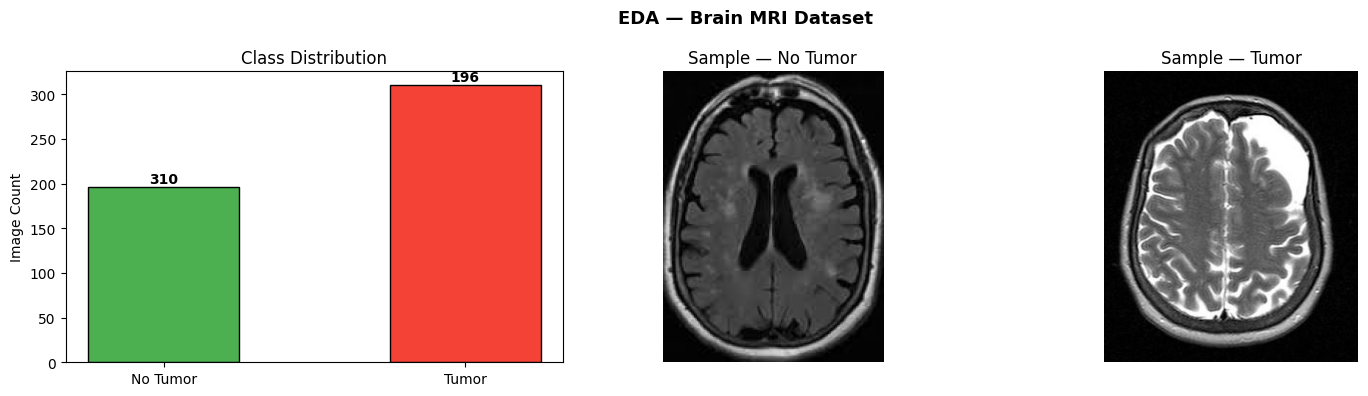

In [6]:
# ── Class distribution bar chart ──────────────────────────────────────────
class_counts = {cls: len(paths) for cls, paths in all_images.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Brain MRI Dataset", fontsize=13, fontweight="bold")

# Bar chart
bars = axes[0].bar(
    ["No Tumor", "Tumor"],
    [class_counts["no"], class_counts["yes"]],
    color=["#4CAF50", "#F44336"], edgecolor="black", width=0.5
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Image Count")
for bar, v in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha="center", va="bottom", fontweight="bold")

# Sample no-tumor image with intensity histogram
no_sample = cv2.imread(all_images["no"][0])
no_gray   = cv2.cvtColor(no_sample, cv2.COLOR_BGR2GRAY)
axes[1].imshow(cv2.cvtColor(no_sample, cv2.COLOR_BGR2RGB))
axes[1].set_title("Sample — No Tumor")
axes[1].axis("off")

# Sample tumor image
yes_sample = cv2.imread(all_images["yes"][0])
axes[2].imshow(cv2.cvtColor(yes_sample, cv2.COLOR_BGR2RGB))
axes[2].set_title("Sample — Tumor")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("/tmp/eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()


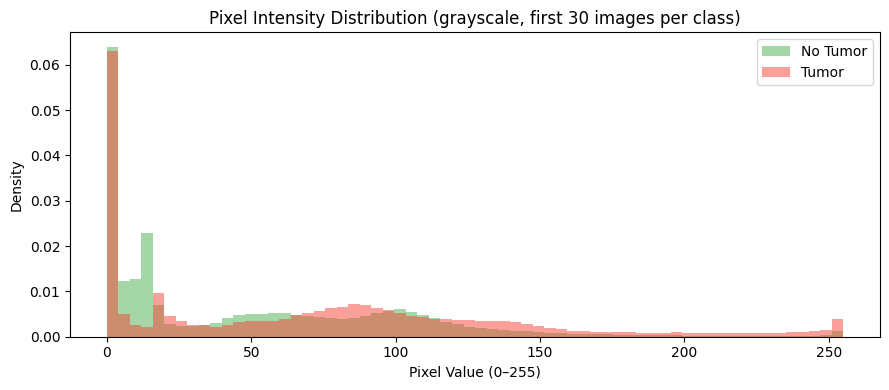

Tumor images tend to show higher-intensity local regions (mass effect).


In [7]:
# ── Pixel intensity comparison ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

for cls, color, label in [("no", "#4CAF50", "No Tumor"), ("yes", "#F44336", "Tumor")]:
    sample_paths = all_images[cls][:30]
    pixels = []
    for p in sample_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    ax.hist(pixels, bins=64, alpha=0.5, color=color, label=label, density=True)

ax.set_title("Pixel Intensity Distribution (grayscale, first 30 images per class)")
ax.set_xlabel("Pixel Value (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/pixel_intensity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Tumor images tend to show higher-intensity local regions (mass effect).")


In [8]:
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = 15,
    zoom_range         = 0.10,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    brightness_range   = [0.85, 1.15],
    fill_mode          = "nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    classes     = CLASSES,
    seed        = SEED,
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    classes     = CLASSES,
    seed        = SEED,
    shuffle     = False,
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    classes     = CLASSES,
    seed        = SEED,
    shuffle     = False,
)

print(f"Class mapping : {train_gen.class_indices}  (0=no_tumor, 1=tumor)")
print(f"Train samples : {train_gen.samples}")
print(f"Val   samples : {val_gen.samples}")
print(f"Test  samples : {test_gen.samples}")


Found 231 images belonging to 2 classes.
Found 68 images belonging to 2 classes.
Found 71 images belonging to 2 classes.
Class mapping : {'no': 0, 'yes': 1}  (0=no_tumor, 1=tumor)
Train samples : 231
Val   samples : 68
Test  samples : 71


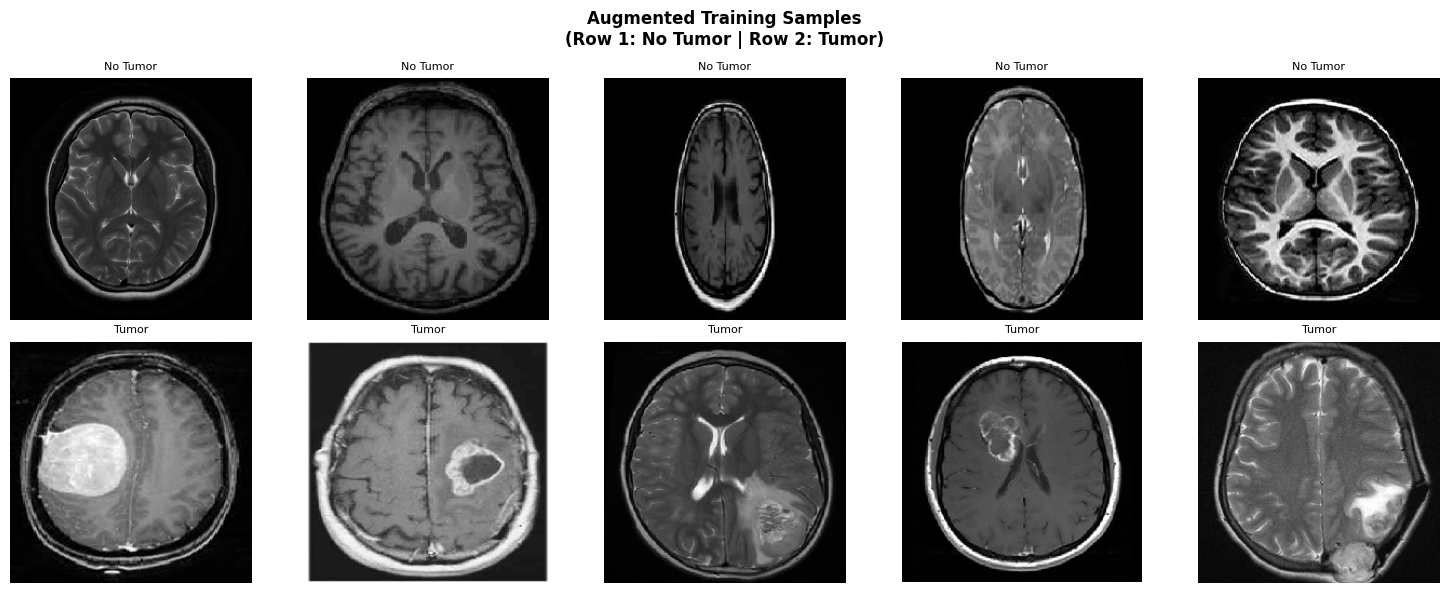

In [9]:
# ── Visualise augmented samples ───────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Augmented Training Samples\n(Row 1: No Tumor | Row 2: Tumor)",
             fontsize=12, fontweight="bold")

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_DIR, "train", cls)
    img_files = sorted(os.listdir(cls_dir))[:5]
    for col, fname in enumerate(img_files):
        img = load_img(os.path.join(cls_dir, fname),
                       target_size=(IMG_SIZE, IMG_SIZE))
        axes[row, col].imshow(img)
        axes[row, col].set_title("Tumor" if cls == "yes" else "No Tumor", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("/tmp/augmented_samples.png", dpi=120, bbox_inches="tight")
plt.show()


In [10]:
def build_model(img_size=224, lr=1e-3):
    """
    EfficientNetB0-based binary classifier with custom head.

    Returns a compiled Keras Model ready for Phase-1 training.
    The EfficientNetB0 base is frozen; only the head trains.
    """
    base = EfficientNetB0(
        include_top  = False,
        weights      = "imagenet",
        input_shape  = (img_size, img_size, 3),
    )
    base.trainable = False   # frozen in Phase 1

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x      = base(inputs, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dense(512, activation="swish")(x)
    x      = layers.Dropout(0.45)(x)
    x      = layers.Dense(256, activation="swish")(x)
    x      = layers.Dropout(0.30)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, output, name="BrainTumorEfficientNet")
    model.compile(
        optimizer = keras.optimizers.Adam(lr),
        loss      = "binary_crossentropy",
        metrics   = ["accuracy",
                     keras.metrics.AUC(name="auc"),
                     keras.metrics.Recall(name="recall")],
    )
    return model, base

model, efficientnet_base = build_model()
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "BrainTumorEfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,148 (18.47 MB)

 Trainable params: 790,017 (3.01 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [11]:
callbacks_phase1 = [
    EarlyStopping(monitor="val_auc", patience=8, restore_best_weights=True,
                  mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint("/tmp/best_model_phase1.keras", save_best_only=True,
                    monitor="val_auc", mode="max", verbose=0),
]

print("⚙️  Phase 1: training head only (EfficientNetB0 base frozen)...")
history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks_phase1,
    verbose         = 1,
)
print("\n✅ Phase 1 complete.")


⚙️  Phase 1: training head only (EfficientNetB0 base frozen)...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.4935 - auc: 0.4558 - loss: 0.9014 - recall: 0.5423 - val_accuracy: 0.3971 - val_auc: 0.5303 - val_loss: 0.6962 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.5152 - auc: 0.5106 - loss: 0.9715 - recall: 0.5775 - val_accuracy: 0.6029 - val_auc: 0.5253 - val_loss: 0.6784 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 308ms/step - accuracy: 0.5628 - auc: 0.4963 - loss: 1.1050 - recall: 0.7254 - val_accuracy: 0.6029 - val_auc: 0.6879 - val_loss: 0.6713 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.5195 - auc: 0.4654 - loss: 1.0092 - recall: 0.5845 - val_accuracy: 0.6029 - val_auc: 0.5370 - val_loss: 0.6800 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms

In [12]:
# ── Unfreeze top 20 layers of the EfficientNetB0 base ────────────────────
efficientnet_base.trainable = True
FREEZE_UNTIL = len(efficientnet_base.layers) - 20

for i, layer in enumerate(efficientnet_base.layers):
    layer.trainable = (i >= FREEZE_UNTIL)

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable_count}")

# Recompile with a lower learning rate
model.compile(
    optimizer = keras.optimizers.Adam(1e-5),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Recall(name="recall")],
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_auc", patience=10, restore_best_weights=True,
                  mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.4, patience=5,
                      min_lr=1e-8, verbose=1),
    ModelCheckpoint("/tmp/best_model_final.keras", save_best_only=True,
                    monitor="val_auc", mode="max", verbose=0),
]

print("\n⚙️  Phase 2: fine-tuning top 20 EfficientNetB0 layers...")
history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    callbacks       = callbacks_phase2,
    verbose         = 1,
)
print("\n✅ Phase 2 complete.")


Trainable layers after unfreezing: 9

⚙️  Phase 2: fine-tuning top 20 EfficientNetB0 layers...
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.6234 - auc: 0.5446 - loss: 0.6811 - recall: 0.8944 - val_accuracy: 0.6029 - val_auc: 0.8135 - val_loss: 0.6695 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.6147 - auc: 0.5331 - loss: 0.6808 - recall: 0.8662 - val_accuracy: 0.6029 - val_auc: 0.8004 - val_loss: 0.6709 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.5974 - auc: 0.5106 - loss: 0.6849 - recall: 0.8803 - val_accuracy: 0.6765 - val_auc: 0.7728 - val_loss: 0.6882 - val_recall: 0.9756 - learning_rate: 1.0000e-05
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 293ms/step - accuracy: 0.5931 - auc: 0.5474 - loss: 0.6693 - recall: 0.8662 - val_accuracy: 0.3971 - val_auc: 0.7895 - val_loss: 0.6956 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05

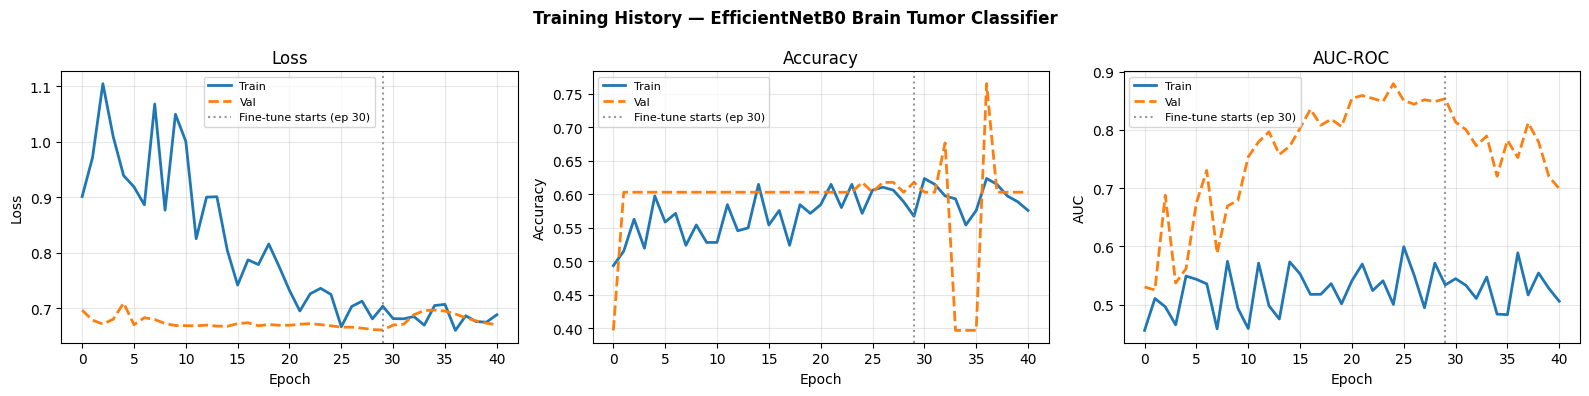

In [13]:
# ── Combine Phase 1 + Phase 2 history ────────────────────────────────────
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history1, history2)
phase1_end = len(history1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training History — EfficientNetB0 Brain Tumor Classifier",
             fontsize=12, fontweight="bold")

metrics = [
    ("loss",     "Loss",     "Loss"),
    ("accuracy", "Accuracy", "Accuracy"),
    ("auc",      "AUC-ROC",  "AUC"),
]

for ax, (metric, title, ylabel) in zip(axes, metrics):
    ax.plot(history[metric],          label="Train", linewidth=2)
    ax.plot(history[f"val_{metric}"], label="Val",   linewidth=2, linestyle="--")
    ax.axvline(phase1_end - 1, color="gray", linestyle=":", alpha=0.8,
               label=f"Fine-tune starts (ep {phase1_end})")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/training_curves.png", dpi=130, bbox_inches="tight")
plt.show()


In [14]:
# ── Predictions ──────────────────────────────────────────────────────────
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))


5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

📊 Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00        28
       Tumor       0.61      1.00      0.75        43

    accuracy                           0.61        71
   macro avg       0.30      0.50      0.38        71
weighted avg       0.37      0.61      0.46        71



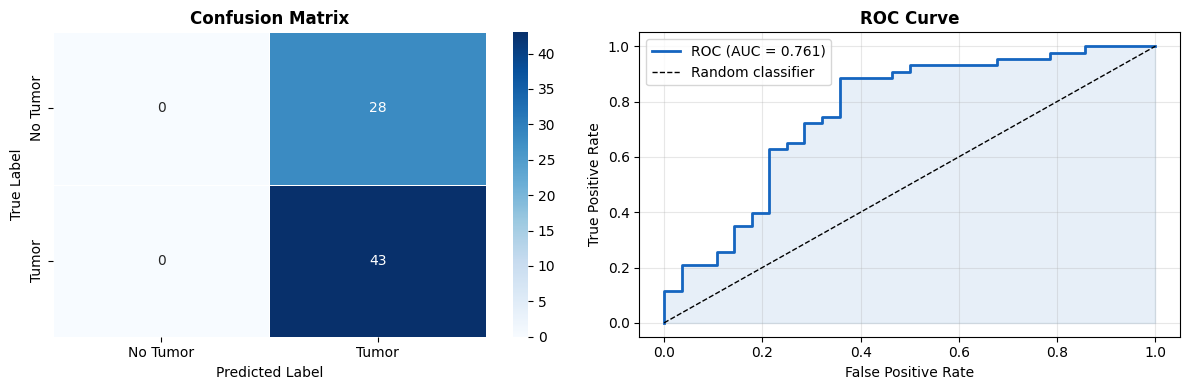

Sensitivity (Recall)  : 1.000
Specificity           : 0.000
AUC-ROC               : 0.761


In [15]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm_vals = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_vals, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"],
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#1565C0", lw=2,
             label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#1565C0")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/evaluation.png", dpi=130, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm_vals.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"Sensitivity (Recall)  : {sensitivity:.3f}")
print(f"Specificity           : {specificity:.3f}")
print(f"AUC-ROC               : {roc_auc:.3f}")


In [19]:
# Step 1: Run this to inspect your model's layer structure
for layer in model.layers:
    print(type(layer).__name__, "->", layer.name)

InputLayer -> input_layer_1
Functional -> efficientnetb0
GlobalAveragePooling2D -> global_average_pooling2d
BatchNormalization -> batch_normalization
Dense -> dense
Dropout -> dropout
Dense -> dense_1
Dropout -> dropout_1
Dense -> dense_2


In [20]:
# Step 2: Find the EfficientNetB0 sub-model directly by name
efficientnet_sub = model.get_layer("efficientnetb0")  # adjust name if Step 1 shows differently

for sub_layer in reversed(efficientnet_sub.layers):
    print(type(sub_layer).__name__, "->", sub_layer.name,
          "->", getattr(sub_layer, "output_shape", "NO_SHAPE"))

Activation -> top_activation -> NO_SHAPE
BatchNormalization -> top_bn -> NO_SHAPE
Conv2D -> top_conv -> NO_SHAPE
BatchNormalization -> block7a_project_bn -> NO_SHAPE
Conv2D -> block7a_project_conv -> NO_SHAPE
Multiply -> block7a_se_excite -> NO_SHAPE
Conv2D -> block7a_se_expand -> NO_SHAPE
Conv2D -> block7a_se_reduce -> NO_SHAPE
Reshape -> block7a_se_reshape -> NO_SHAPE
GlobalAveragePooling2D -> block7a_se_squeeze -> NO_SHAPE
Activation -> block7a_activation -> NO_SHAPE
BatchNormalization -> block7a_bn -> NO_SHAPE
DepthwiseConv2D -> block7a_dwconv -> NO_SHAPE
Activation -> block7a_expand_activation -> NO_SHAPE
BatchNormalization -> block7a_expand_bn -> NO_SHAPE
Conv2D -> block7a_expand_conv -> NO_SHAPE
Add -> block6d_add -> NO_SHAPE
Dropout -> block6d_drop -> NO_SHAPE
BatchNormalization -> block6d_project_bn -> NO_SHAPE
Conv2D -> block6d_project_conv -> NO_SHAPE
Multiply -> block6d_se_excite -> NO_SHAPE
Conv2D -> block6d_se_expand -> NO_SHAPE
Conv2D -> block6d_se_reduce -> NO_SHAPE
Res

In [21]:
# Step 3: Direct approach — no layer scanning needed
base_name  = "efficientnetb0"          # adjust if Step 1 shows a different name
last_conv  = "top_conv"                # last Conv2D in EfficientNetB0 before pooling

print(f"Base sub-model : {base_name}")
print(f"Last conv layer: {last_conv}")

Base sub-model : efficientnetb0
Last conv layer: top_conv


In [23]:
def compute_gradcam_plus_plus(model, img_array, layer_name, base_model_name):
    """
    Compute a Grad-CAM++ heatmap for the tumor class (index 1 in sigmoid).

    Parameters
    ----------
    model          : compiled Keras Model
    img_array      : (1, H, W, 3) float32 array in [0, 1]
    layer_name     : name of the target conv layer inside the base sub-model
    base_model_name: name of the EfficientNetB0 sub-model layer

    Returns
    -------
    heatmap        : (H_conv, W_conv) float32 array in [0, 1]
    """
    # Build a sub-model that outputs (feature_maps, final_prediction)
    base_sub = model.get_layer(base_model_name)
    conv_output_model = keras.Model(
        inputs  = base_sub.input,
        outputs = [base_sub.get_layer(layer_name).output,
                   base_sub.output],
    )

    # Full gradient tape: conv outputs and class score
    with tf.GradientTape(persistent=True) as tape:
        conv_outputs, base_out = conv_output_model(img_array, training=False)
        tape.watch(conv_outputs)
        # Pool base output and pass through head layers
        x = model.get_layer("global_average_pooling2d")(base_out)
        for lname in ["batch_normalization", "dense", "dropout",
                      "dense_1", "dropout_1", "dense_2"]:
            try:
                x = model.get_layer(lname)(x)
            except Exception:
                pass
        score = x   # scalar in (0,1)

    # First-order gradient
    grads        = tape.gradient(score, conv_outputs)        # (1, h, w, c)
    # Second-order (numerator of alpha)
    grads_sq     = grads ** 2
    grads_cube   = grads ** 3
    # Global sum for denominator
    sum_acts     = tf.reduce_sum(conv_outputs, axis=(1, 2), keepdims=True)  # (1,1,1,c)
    eps          = 1e-7
    alpha_denom  = 2.0 * grads_sq + sum_acts * grads_cube + eps
    alpha        = grads_sq / alpha_denom                                   # (1,h,w,c)
    # Positive-weighted sum
    weights      = tf.reduce_sum(
        alpha * tf.nn.relu(grads), axis=(1, 2), keepdims=True)              # (1,1,1,c)
    # Weighted combination of conv maps
    cam          = tf.reduce_sum(weights * conv_outputs, axis=-1)           # (1,h,w)
    cam          = tf.nn.relu(cam)[0].numpy()

    # Normalise to [0, 1]
    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    return cam


def overlay_heatmap(img_arr, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """Resize heatmap and overlay it on the original image."""
    h, w    = img_arr.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_rgb     = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    img_uint8       = np.uint8(255 * img_arr)
    overlay         = cv2.addWeighted(img_uint8, 1 - alpha,
                                      heatmap_rgb, alpha, 0)
    return overlay, heatmap_rgb

print("✅ Grad-CAM++ functions defined.")


✅ Grad-CAM++ functions defined.


In [25]:
def load_img_array(path, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load image → normalised float32 array."""
    img = load_img(path, target_size=target_size)
    arr = img_to_array(img) / 255.0
    return arr

# ── Sample images for XAI ─────────────────────────────────────────────────
xai_samples = {}
for cls in CLASSES:
    cls_dir   = os.path.join(DATA_DIR, "test", cls)
    img_files = sorted(os.listdir(cls_dir))[:3]
    xai_samples[cls] = [os.path.join(cls_dir, f) for f in img_files]

print("XAI test samples selected:")
for cls, paths in xai_samples.items():
    print(f"  {cls}: {len(paths)} images")


XAI test samples selected:
  no: 3 images
  yes: 3 images


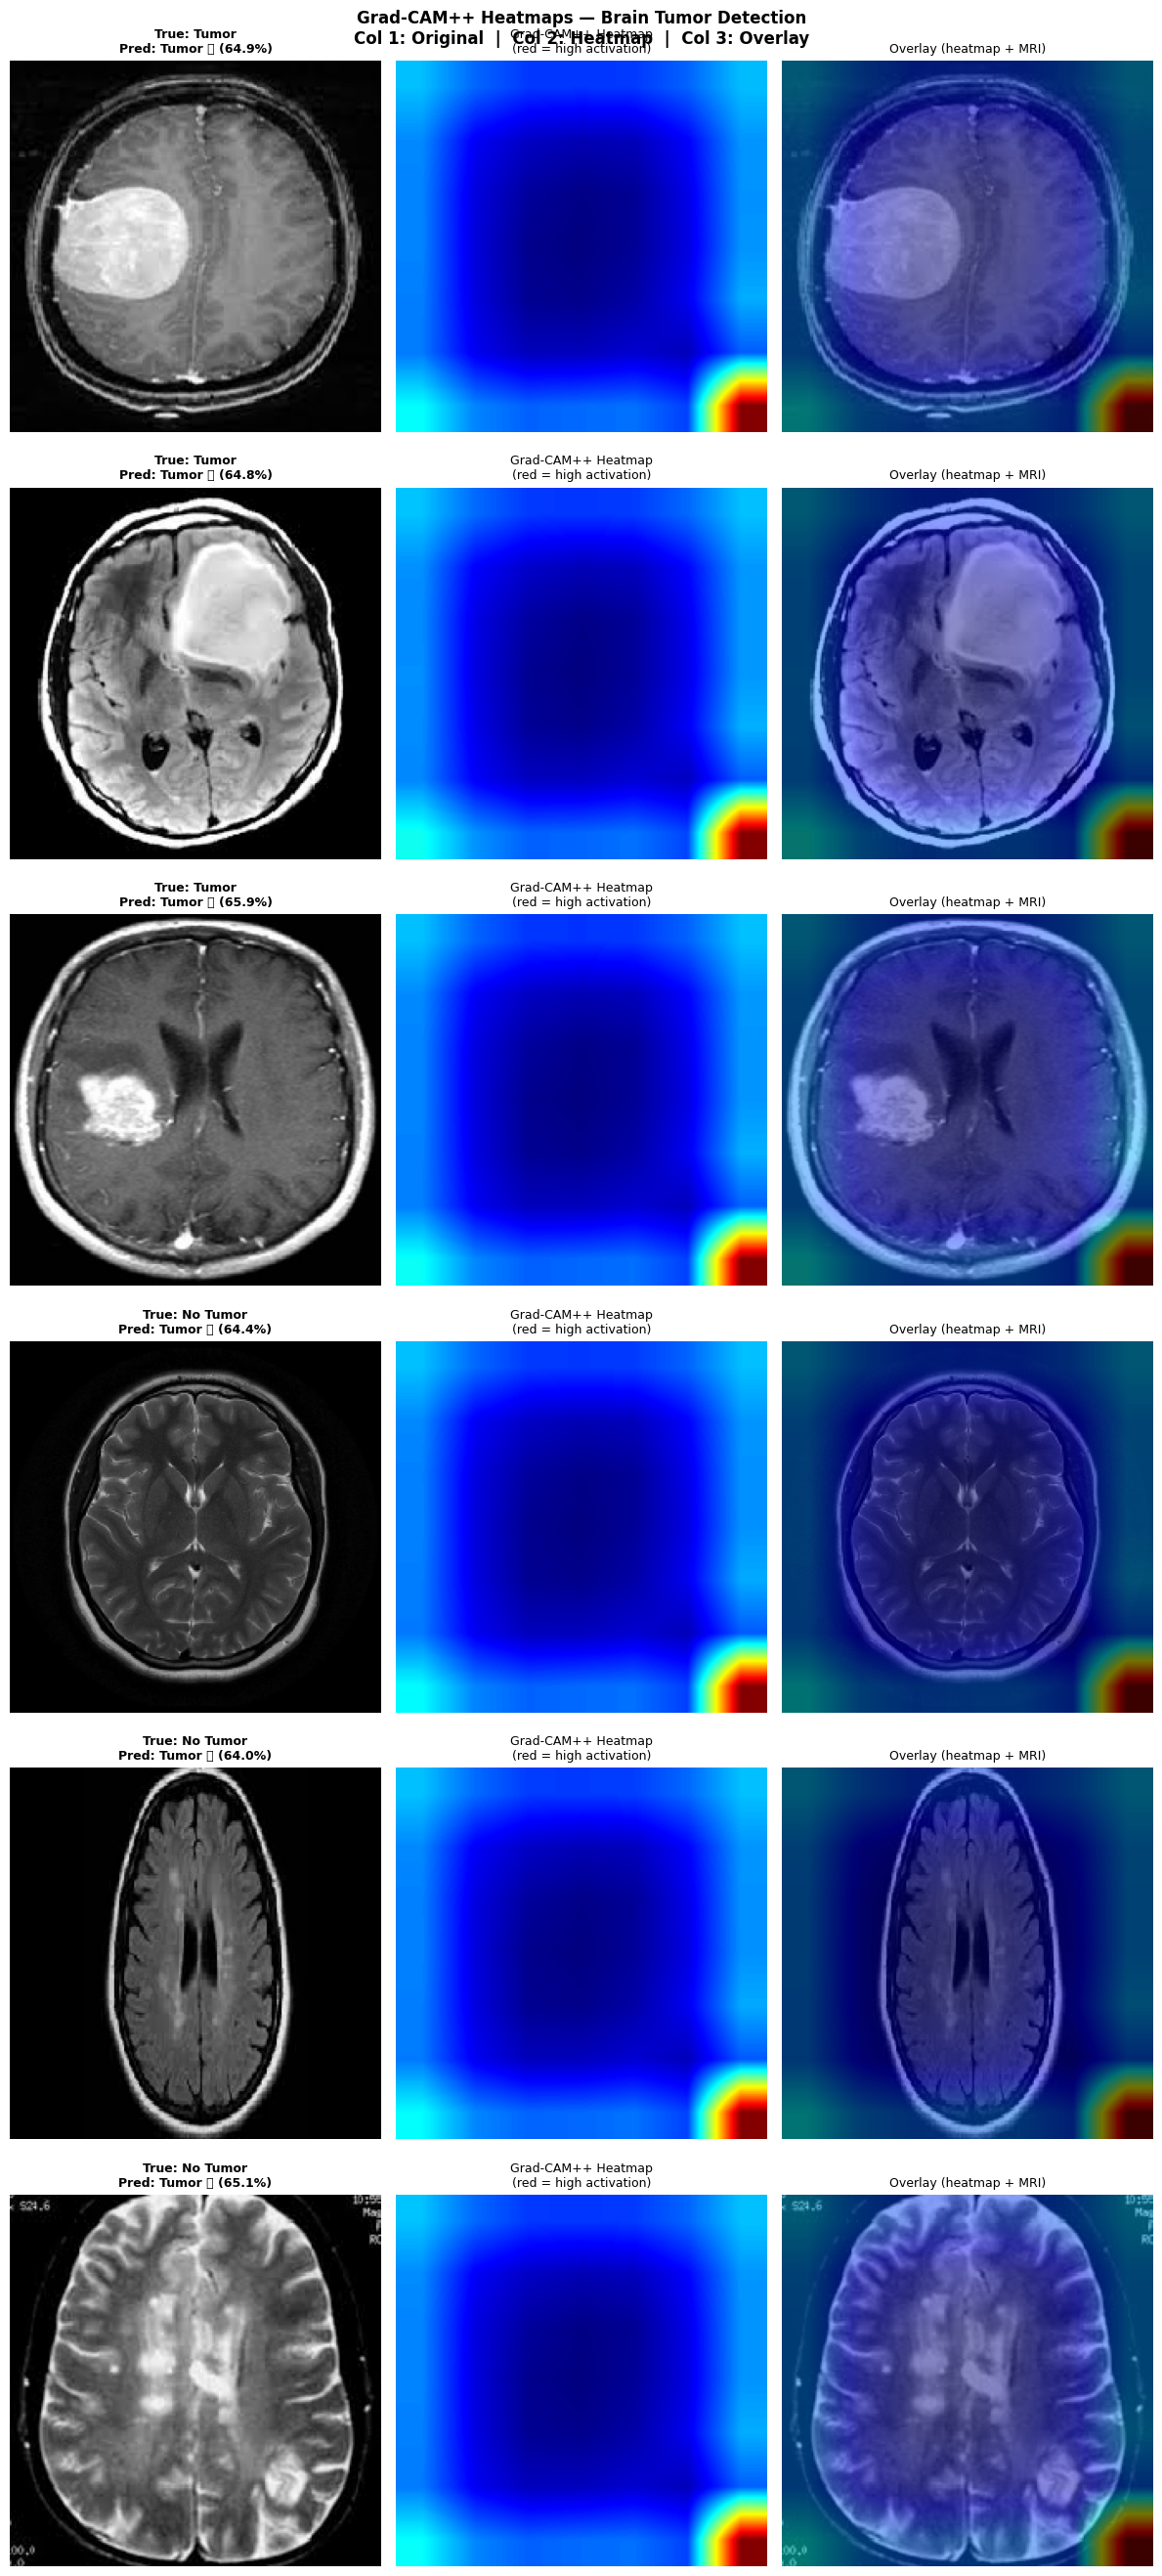

✅ Grad-CAM++ figure saved.


In [26]:
# ── Grad-CAM++ Visualisation ──────────────────────────────────────────────
all_xai = [(p, "yes") for p in xai_samples["yes"]] +           [(p, "no")  for p in xai_samples["no"]]

fig, axes = plt.subplots(len(all_xai), 3, figsize=(12, 4.5 * len(all_xai)))
fig.suptitle("Grad-CAM++ Heatmaps — Brain Tumor Detection\n"
             "Col 1: Original  |  Col 2: Heatmap  |  Col 3: Overlay",
             fontsize=12, fontweight="bold")

for row, (img_path, true_cls) in enumerate(all_xai):
    arr       = load_img_array(img_path)
    batch     = np.expand_dims(arr, 0).astype(np.float32)
    prob      = float(model.predict(batch, verbose=0)[0][0])
    pred_lbl  = "Tumor" if prob >= 0.5 else "No Tumor"
    true_lbl  = "Tumor" if true_cls == "yes" else "No Tumor"
    correct   = "✅" if pred_lbl == true_lbl else "❌"

    try:
        heatmap            = compute_gradcam_plus_plus(model, batch, last_conv, base_name)
        overlay, hmap_rgb  = overlay_heatmap(arr, heatmap)
    except Exception as e:
        print(f"  Warning: Grad-CAM++ failed for {img_path}: {e}")
        hmap_rgb = np.zeros_like(np.uint8(arr * 255))
        overlay  = np.uint8(arr * 255)

    # Original
    axes[row, 0].imshow(arr)
    axes[row, 0].set_title(f"True: {true_lbl}\nPred: {pred_lbl} {correct} ({prob:.1%})",
                           fontsize=9, fontweight="bold")
    axes[row, 0].axis("off")

    # Heatmap only
    axes[row, 1].imshow(hmap_rgb)
    axes[row, 1].set_title("Grad-CAM++ Heatmap\n(red = high activation)", fontsize=9)
    axes[row, 1].axis("off")

    # Overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay (heatmap + MRI)", fontsize=9)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("/tmp/gradcam_plus_plus.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Grad-CAM++ figure saved.")


In [33]:
# ── XAI Part B: Integrated Gradients ─────────────────────────────────────

def integrated_gradients(model, img_array, baseline=None, steps=50):
    """
    Compute Integrated Gradients attribution map.

    Parameters
    ----------
    model      : Keras model
    img_array  : (1, H, W, 3) float32 in [0, 1]
    baseline   : reference input — black image by default
    steps      : number of interpolation steps (higher = more accurate)

    Returns
    -------
    ig_map     : (H, W, 3) attribution array (signed)
    """
    if baseline is None:
        baseline = tf.zeros_like(img_array)

    # Interpolate between baseline and input
    alphas      = tf.linspace(0.0, 1.0, steps + 1)           # (steps+1,)
    interpolated = baseline + alphas[:, None, None, None] * (img_array - baseline)
                                                               # (steps+1, H, W, 3)
    # Compute gradients at each interpolated point
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)            # (steps+1, 1)

    grads = tape.gradient(preds, interpolated)                 # (steps+1, H, W, 3)

    # Approximate the integral via trapezoidal rule
    grads  = (grads[:-1] + grads[1:]) / 2.0                  # (steps, H, W, 3)
    avg_grads = tf.reduce_mean(grads, axis=0)                  # (H, W, 3)

    # Scale by input − baseline
    ig = (img_array[0] - baseline[0]) * avg_grads             # (H, W, 3)
    return ig.numpy()


print("✅ Integrated Gradients function defined.")

✅ Integrated Gradients function defined.


LookupError: gradient registry has no entry for: shap_BiasAdd

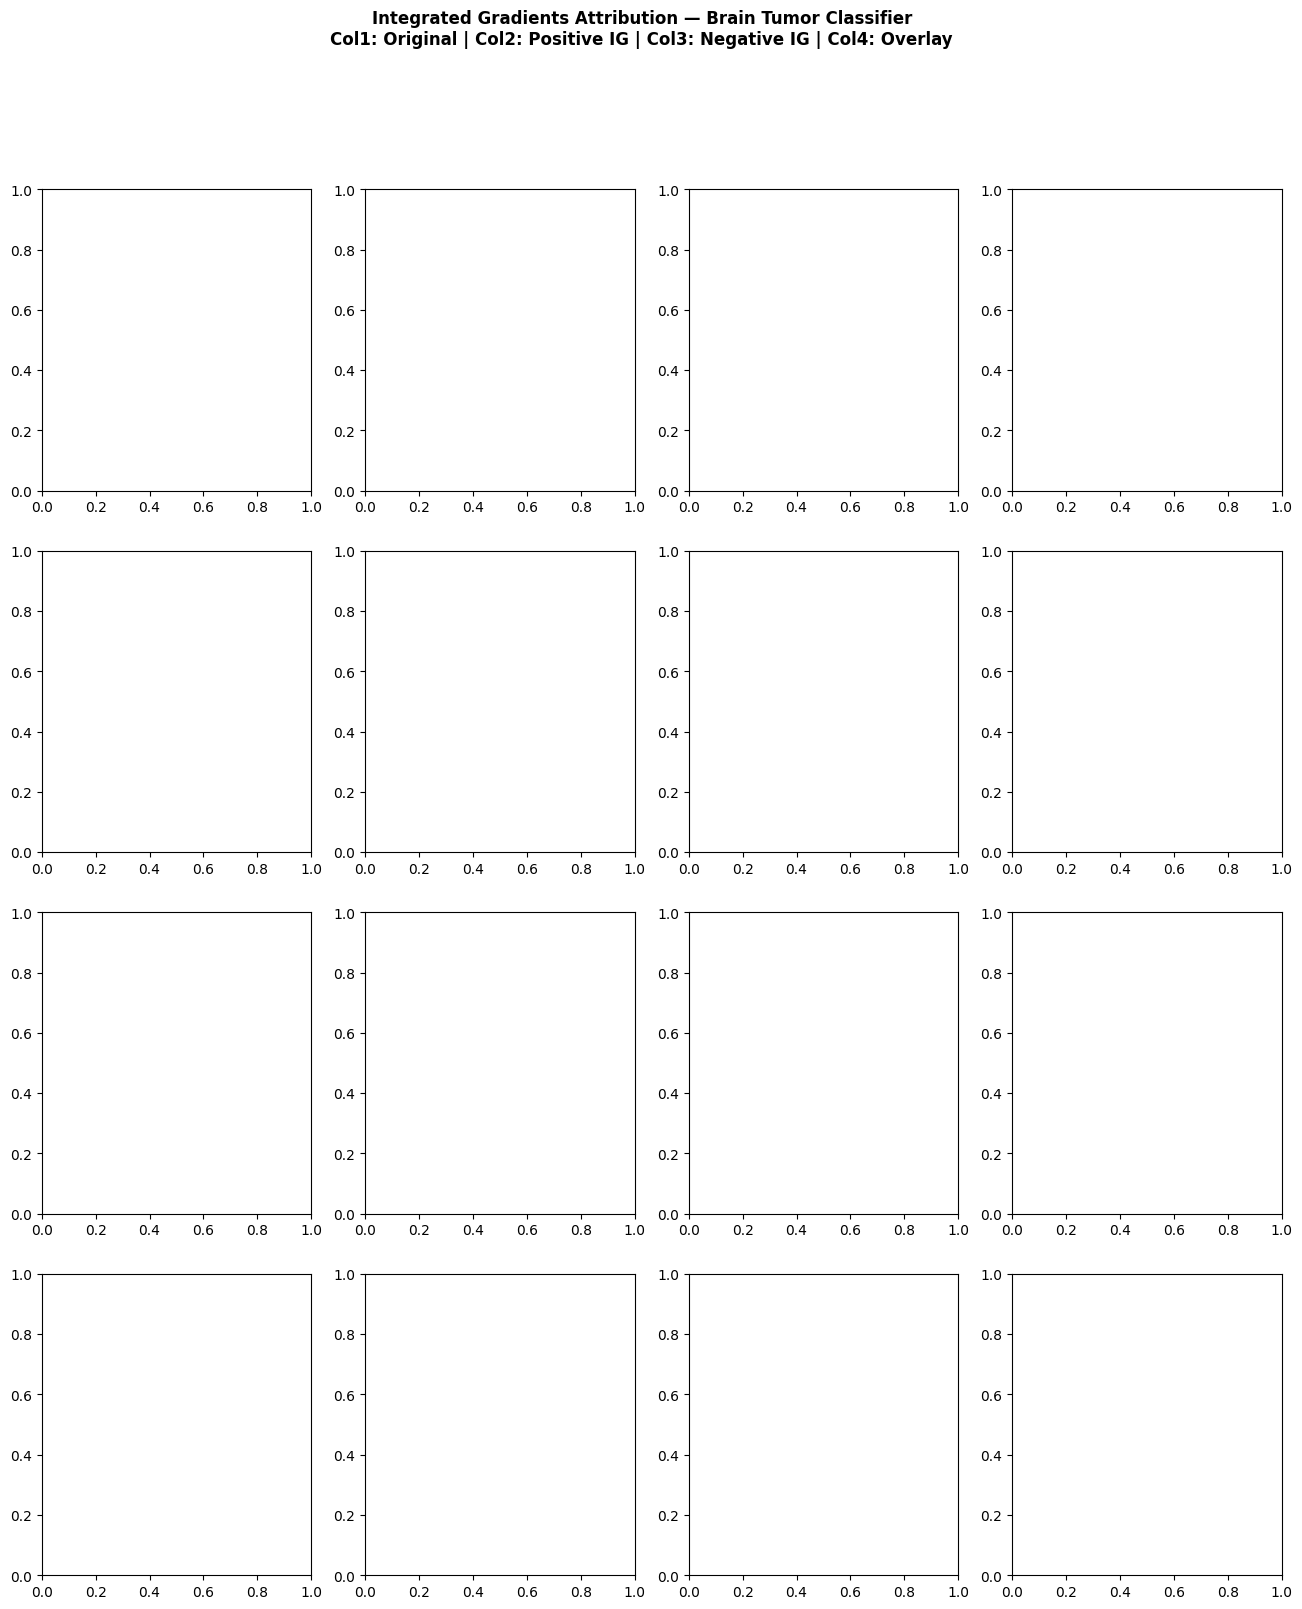

In [35]:
# ── Compute & Visualise ───────────────────────────────────────────────────
test_paths   = xai_samples["yes"][:2] + xai_samples["no"][:2]
true_classes = ["yes"] * 2 + ["no"] * 2

fig, axes = plt.subplots(len(test_paths), 4,
                         figsize=(16, 4.5 * len(test_paths)))
fig.suptitle("Integrated Gradients Attribution — Brain Tumor Classifier\n"
             "Col1: Original | Col2: Positive IG | Col3: Negative IG | Col4: Overlay",
             fontsize=12, fontweight="bold")

for i, (img_path, true_cls) in enumerate(zip(test_paths, true_classes)):
    arr      = load_img_array(img_path)
    batch    = tf.constant(np.expand_dims(arr, 0), dtype=tf.float32)
    prob     = float(model.predict(batch, verbose=0)[0][0])
    pred_lbl = "Tumor" if prob >= 0.5 else "No Tumor"
    true_lbl = "Tumor" if true_cls == "yes" else "No Tumor"
    correct  = "✅" if pred_lbl == true_lbl else "❌"

    ig      = integrated_gradients(model, batch, steps=50)
    ig_map  = ig.sum(axis=-1)
    abs_max = np.percentile(np.abs(ig_map), 97)

    pos_map = np.where(ig_map > 0, ig_map, 0)
    neg_map = np.where(ig_map < 0, ig_map, 0)

    axes[i, 0].imshow(arr)
    axes[i, 0].set_title(f"True: {true_lbl}\nPred: {pred_lbl} {correct} ({prob:.1%})",
                         fontsize=9, fontweight="bold")
    axes[i, 0].axis("off")

    im1 = axes[i, 1].imshow(pos_map, cmap="Reds", vmin=0, vmax=abs_max)
    axes[i, 1].set_title("Positive IG\n(→ Tumor)", fontsize=9)
    axes[i, 1].axis("off")
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    im2 = axes[i, 2].imshow(neg_map, cmap="Blues_r", vmin=-abs_max, vmax=0)
    axes[i, 2].set_title("Negative IG\n(→ No Tumor)", fontsize=9)
    axes[i, 2].axis("off")
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

    ig_norm = np.clip(ig_map / (abs_max + 1e-7), -1, 1)
    r_ch    = np.where(ig_norm > 0, ig_norm, 0)
    b_ch    = np.where(ig_norm < 0, -ig_norm, 0)
    overlay = arr * 0.45 + np.stack([r_ch, np.zeros_like(r_ch), b_ch], axis=-1) * 0.55
    axes[i, 3].imshow(np.clip(overlay, 0, 1))
    axes[i, 3].set_title("IG Overlay\n(red=+tumor, blue=+healthy)", fontsize=9)
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("/tmp/integrated_gradients.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Done.")